In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, precision_score,recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

In [2]:
#Load Data
df = pd.read_csv('heart_disease_dataset.csv')  
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (10485, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,4,127,213,0,1,118,1,0.3,1,2,3,0
1,57,1,3,125,251,1,1,115,1,2.9,1,1,7,1
2,43,1,4,146,208,0,0,181,1,2.2,2,0,7,1
3,71,0,4,129,189,0,0,131,0,1.1,2,0,3,0
4,36,1,2,137,199,0,0,144,0,2.4,1,1,7,0


In [3]:
#  Dataset Summary 
print('\n Summary of the dataset:')
df.info()
print('\n Descriptive Statistics:')
df.describe()


 Summary of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10485 non-null  int64  
 1   sex       10485 non-null  int64  
 2   cp        10485 non-null  int64  
 3   trestbps  10485 non-null  int64  
 4   chol      10485 non-null  int64  
 5   fbs       10485 non-null  int64  
 6   restecg   10485 non-null  int64  
 7   thalach   10485 non-null  int64  
 8   exang     10485 non-null  int64  
 9   oldpeak   10485 non-null  float64
 10  slope     10485 non-null  int64  
 11  ca        10485 non-null  int64  
 12  thal      10485 non-null  int64  
 13  target    10485 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 1.1 MB

 Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000
mean,53.086981,0.681640,3.154316,130.322556,245.846543,0.148689,0.519313,149.767096,0.324940,1.028622,1.661516,0.673152,4.765093,0.532856
std,14.089310,0.465862,0.969209,16.678752,51.695822,0.355798,0.535940,22.626244,0.468375,1.007712,0.683492,0.936606,1.941593,0.498943
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,41.000000,0.000000,3.000000,119.000000,210.000000,0.000000,0.000000,134.000000,0.000000,0.300000,1.000000,0.000000,3.000000,0.000000
50%,53.000000,1.000000,3.000000,130.000000,246.000000,0.000000,1.000000,150.000000,0.000000,0.700000,2.000000,0.000000,3.000000,1.000000
75%,65.000000,1.000000,4.000000,142.000000,281.000000,0.000000,1.000000,165.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,193.000000,439.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [4]:
# Data Cleaning 
#  Check missing values FIRST, then remove duplicates 

print('Missing Values per column:')
print(df.isnull().sum())

print(f'\nShape BEFORE removing duplicates: {df.shape}')
print(f'Number of duplicate rows: {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)   # FIX: reset index after dropping

print(f'Shape AFTER removing duplicates: {df.shape}')
print('\nTarget distribution after cleaning:')
print(df['target'].value_counts())

Missing Values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Shape BEFORE removing duplicates: (10485, 14)
Number of duplicate rows: 0
Shape AFTER removing duplicates: (10485, 14)

Target distribution after cleaning:
target
1    5587
0    4898
Name: count, dtype: int64


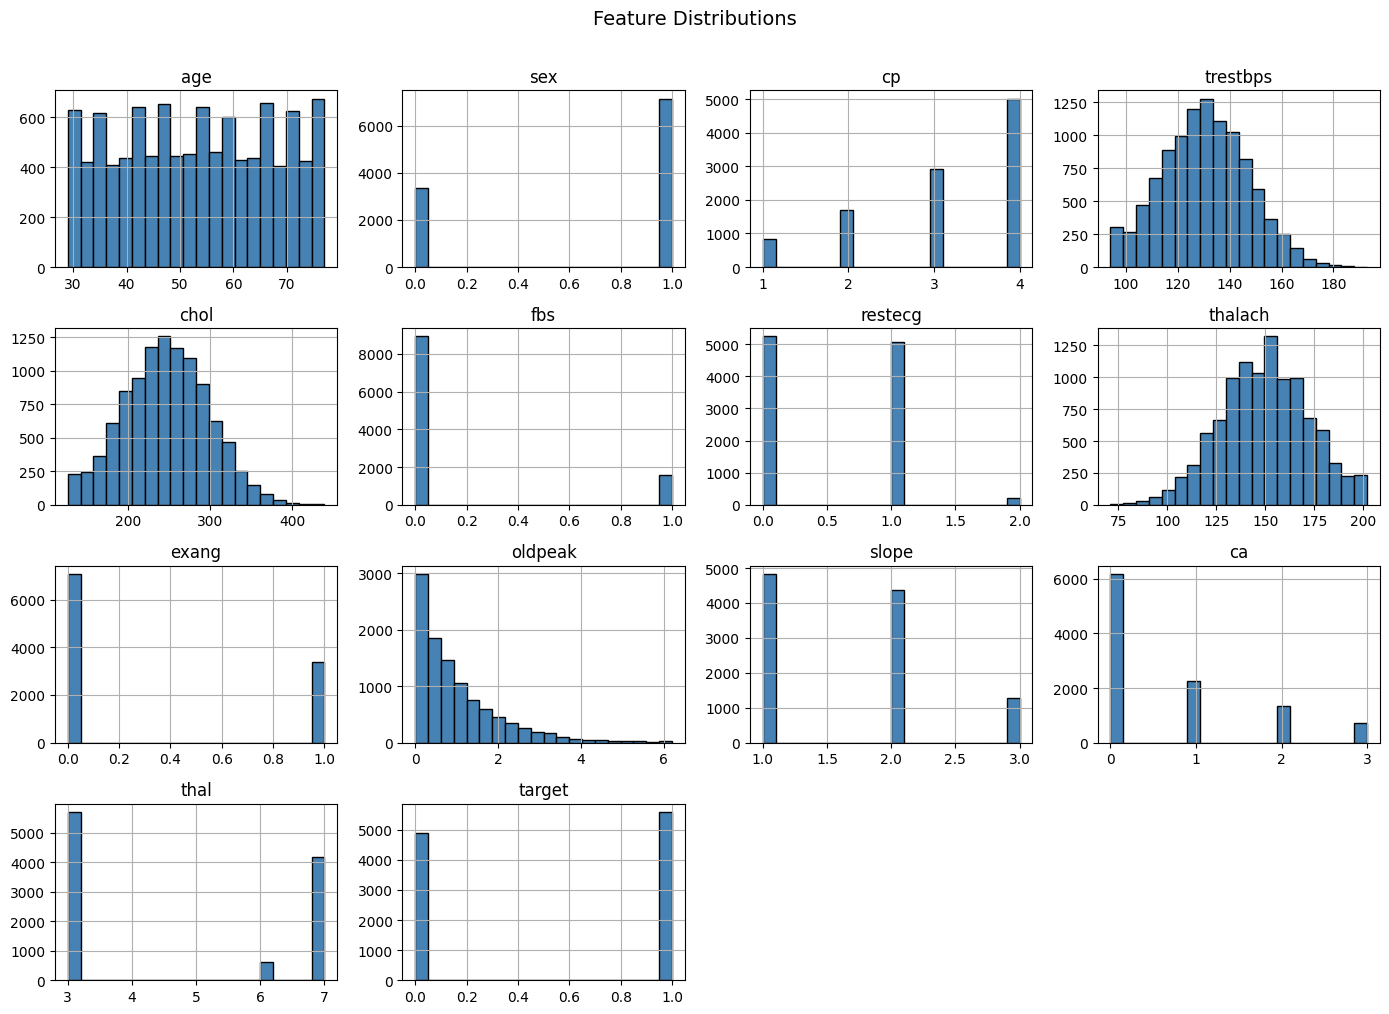

In [5]:
# Histograms
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

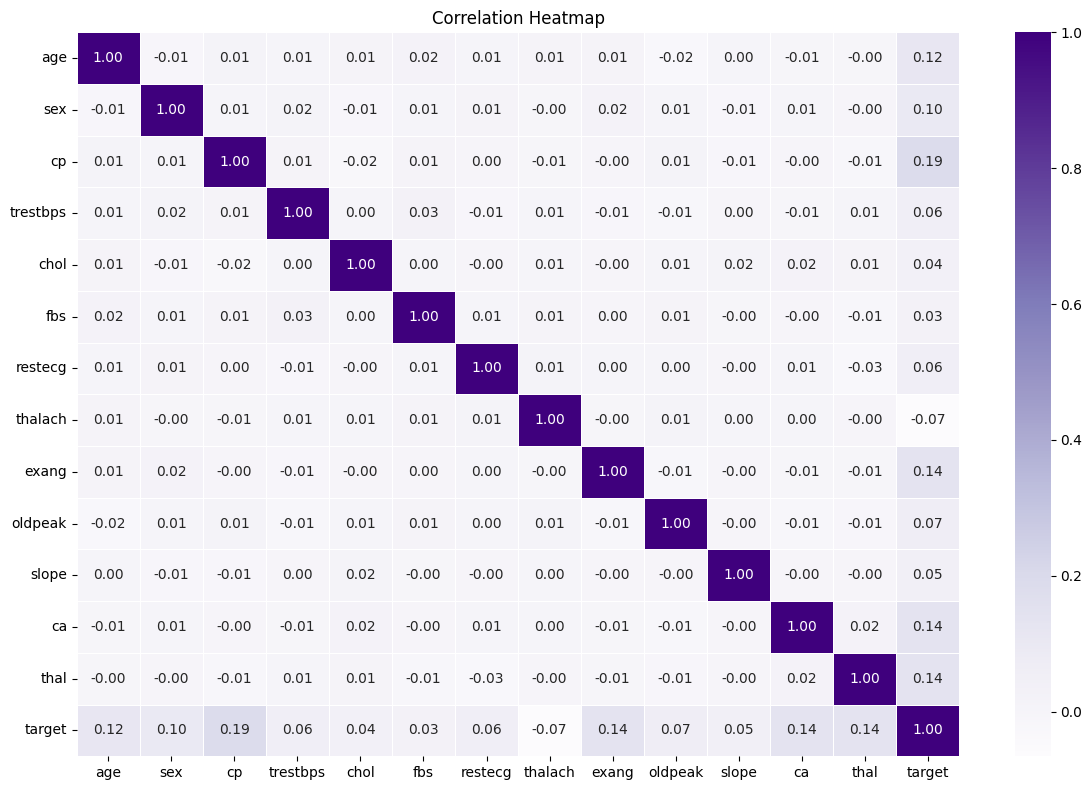

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Purples', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
# One-Hot Encoding 

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)


In [8]:

drop_cols = ['sex_0', 'cp_0', 'fbs_0', 'restecg_0', 'exang_0', 'slp_0']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]  # only drop if exists
df_encoded.drop(columns=drop_cols, inplace=True)

print('Shape after encoding:', df_encoded.shape)
print('Columns:', df_encoded.columns.tolist()) 
df_encoded.head()

Shape after encoding: (10485, 20)
Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal', 'target', 'sex_1', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'fbs_1', 'restecg_1', 'restecg_2', 'exang_1', 'slope_1', 'slope_2', 'slope_3']


,age,trestbps,chol,thalach,oldpeak,ca,thal,target,sex_1,cp_1,cp_2,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,slope_3
0,67,127,213,118,0.3,2,3,0,False,False,False,False,True,False,True,False,True,True,False,False
1,57,125,251,115,2.9,1,7,1,True,False,False,True,False,True,True,False,True,True,False,False
2,43,146,208,181,2.2,0,7,1,True,False,False,False,True,False,False,False,True,False,True,False
3,71,129,189,131,1.1,0,3,0,False,False,False,False,True,False,False,False,False,False,True,False
4,36,137,199,144,2.4,1,7,0,True,False,True,False,False,False,False,False,False,True,False,False


In [9]:
# Feature/Target Split & Train-Test Split (70/30) 
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
continuous_cols = [c for c in continuous_cols if c in df_encoded.columns]

X_raw = df_encoded.drop('target', axis=1)
y = df_encoded['target'].astype(int)


In [10]:

# 70/30 Split (main split used for all models)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.30, random_state=42, stratify=y)


In [11]:

# Fit scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print(f'Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}')
print(f'Target distribution in train:\n{y_train.value_counts()}')
print(f'\nTarget distribution in test:\n{y_test.value_counts()}')

Train size: (7339, 19), Test size: (3146, 19)
Target distribution in train:
target
1    3911
0    3428
Name: count, dtype: int64

Target distribution in test:
target
1    1676
0    1470
Name: count, dtype: int64


In [12]:
# Feature Selection 
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

# Get importance scores
importances = pd.Series(rf_selector.feature_importances_, index=X_train_scaled.columns)

# Pick top 8 features
selected_features = importances.sort_values(ascending=False).head(8).index.tolist()

print('Selected Features:', selected_features)

# Apply selection
X_train = X_train_scaled[selected_features]
X_test = X_test_scaled[selected_features]

Selected Features: ['thalach', 'chol', 'age', 'trestbps', 'oldpeak', 'ca', 'cp_4', 'thal']


In [13]:
#  KNN Classifier
import math
N = len(X_train)
k1 = int(round(math.sqrt(N)))
if k1 % 2 == 0:
    k1 += 1
knn_scores = []
for k in range(1, k1):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    knn_scores.append(knn_temp.score(X_test, y_test))


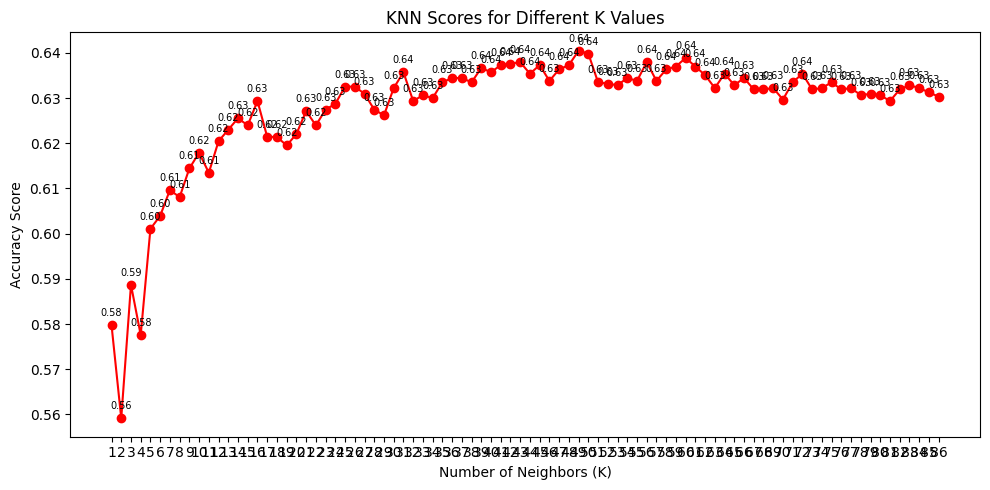

Best K = 49 with accuracy = 64.05%


In [14]:
# Plot KNN scores
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(knn_scores) + 1), knn_scores, color='red', marker='o')
for i in range(len(knn_scores)):
    plt.text(i + 1, knn_scores[i] + 0.002, f'{knn_scores[i]:.2f}', fontsize=7, ha='center')
plt.xticks(range(1, len(knn_scores) + 1))
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('KNN Scores for Different K Values')
plt.tight_layout()
plt.show()

best_k = knn_scores.index(max(knn_scores)) + 1
print(f'Best K = {best_k} with accuracy = {max(knn_scores)*100:.2f}%')

In [15]:
# Best KNN Model ]
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print(f'KNN (K={best_k}) Performance on 70:30 Split')
print(f'Accuracy : {accuracy_score(y_test, knn_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, knn_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, knn_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, knn_pred)*100:.2f}%')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, knn_pred))
print('\nClassification Report:')
print(classification_report(y_test, knn_pred))

KNN (K=49) Performance on 70:30 Split
Accuracy : 64.05%
Precision: 65.58%
Recall   : 68.44%
F1 Score : 66.98%

Confusion Matrix:
[[ 868  602]
 [ 529 1147]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61      1470
           1       0.66      0.68      0.67      1676

    accuracy                           0.64      3146
   macro avg       0.64      0.64      0.64      3146
weighted avg       0.64      0.64      0.64      3146



In [16]:
#  Logistic Regression ─
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
lr_pred = logreg.predict(X_test)

print('Logistic Regression Performance on 70:30 Split')
print(f'Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, lr_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, lr_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, lr_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred))

Logistic Regression Performance on 70:30 Split
Accuracy : 63.45%
Precision: 64.88%
Recall   : 68.44%
F1 Score : 66.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.58      0.60      1470
           1       0.65      0.68      0.67      1676

    accuracy                           0.63      3146
   macro avg       0.63      0.63      0.63      3146
weighted avg       0.63      0.63      0.63      3146



In [17]:
#  SVM - Multiple Kernels 
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svc_scores = []
for kernel in kernels:
    svc_temp = SVC(kernel=kernel, random_state=42)
    svc_temp.fit(X_train, y_train)
    svc_scores.append(svc_temp.score(X_test, y_test))


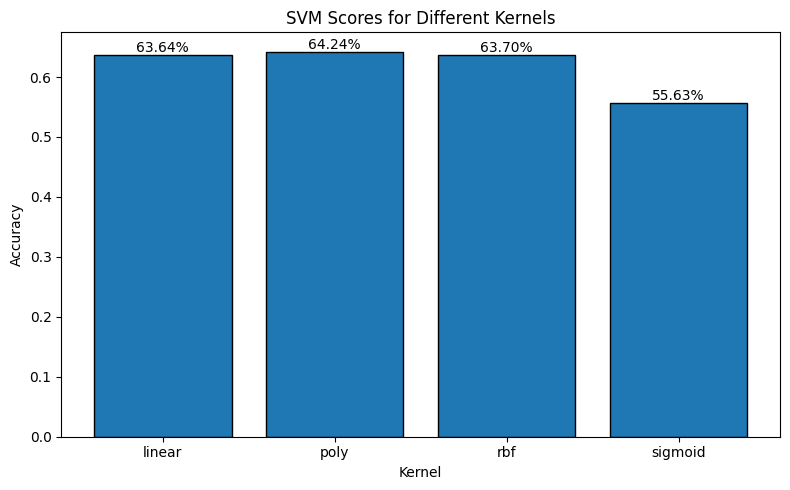

Best SVM Kernel: poly with accuracy = 64.24%


In [18]:

# Plot SVM kernel scores
plt.figure(figsize=(8, 5))
plt.bar(kernels, svc_scores, edgecolor='black')
for i, s in enumerate(svc_scores):
    plt.text(i, s + 0.005, f'{s*100:.2f}%', ha='center', fontsize=10)
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.title('SVM Scores for Different Kernels')
plt.tight_layout()
plt.show()

best_kernel = kernels[svc_scores.index(max(svc_scores))]
print(f'Best SVM Kernel: {best_kernel} with accuracy = {max(svc_scores)*100:.2f}%')

In [19]:
# Best SVM Model
svc = SVC(kernel=best_kernel, random_state=42)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

print(f'SVM ({best_kernel} kernel) Performance on 70:30 Split')
print(f'Accuracy : {accuracy_score(y_test, svc_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, svc_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, svc_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, svc_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, svc_pred))

SVM (poly kernel) Performance on 70:30 Split
Accuracy : 64.24%
Precision: 68.28%
Recall   : 61.40%
F1 Score : 64.66%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64      1470
           1       0.68      0.61      0.65      1676

    accuracy                           0.64      3146
   macro avg       0.64      0.64      0.64      3146
weighted avg       0.65      0.64      0.64      3146



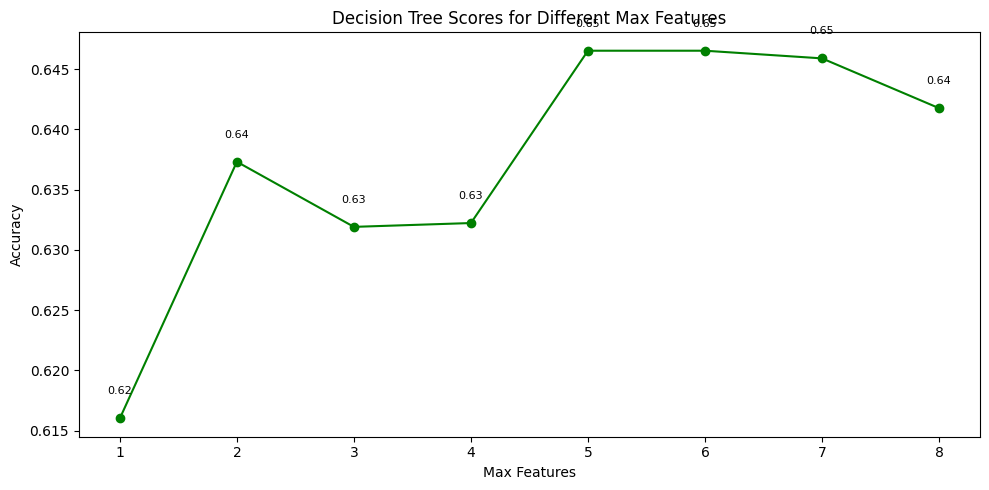

Best max_features = 5 with accuracy = 64.65%


In [20]:
# Decision Tree 
dt_scores = []
for mf in range(1, len(X_train.columns) + 1):
    dt_temp = DecisionTreeClassifier(max_features=mf, max_depth=5, random_state=42)
    dt_temp.fit(X_train, y_train)
    dt_scores.append(dt_temp.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(X_train.columns) + 1), dt_scores, color='green', marker='o')
for i, s in enumerate(dt_scores):
    plt.text(i+1, s + 0.002, f'{s:.2f}', fontsize=8, ha='center')
plt.xticks(range(1, len(X_train.columns) + 1))
plt.xlabel('Max Features')
plt.ylabel('Accuracy')
plt.title('Decision Tree Scores for Different Max Features')
plt.tight_layout()
plt.show()

best_mf = dt_scores.index(max(dt_scores)) + 1
print(f'Best max_features = {best_mf} with accuracy = {max(dt_scores)*100:.2f}%')

In [21]:
#  Best Decision Tree Model
dt = DecisionTreeClassifier(max_features=best_mf, max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print('Decision Tree Performance on 70:30 Split')
print(f'Accuracy : {accuracy_score(y_test, dt_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, dt_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, dt_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, dt_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Performance on 70:30 Split
Accuracy : 64.65%
Precision: 68.77%
Recall   : 61.63%
F1 Score : 65.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.68      0.64      1470
           1       0.69      0.62      0.65      1676

    accuracy                           0.65      3146
   macro avg       0.65      0.65      0.65      3146
weighted avg       0.65      0.65      0.65      3146



In [22]:
# Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest Performance on 70:30 Split')
print(f'Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, rf_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, rf_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, rf_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred))

Random Forest Performance on 70:30 Split
Accuracy : 63.10%
Precision: 64.47%
Recall   : 68.44%
F1 Score : 66.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59      1470
           1       0.64      0.68      0.66      1676

    accuracy                           0.63      3146
   macro avg       0.63      0.63      0.63      3146
weighted avg       0.63      0.63      0.63      3146



In [23]:
# Final Model Comparison 
model_results = {
    'KNN':                 recall_score(y_test, knn_pred) * 100,
    'Logistic Regression':  recall_score(y_test, lr_pred)  * 100,
    f'SVM ({best_kernel})':recall_score(y_test, svc_pred) * 100,
    'Decision Tree':       recall_score(y_test, dt_pred)  * 100,
    'Random Forest':       recall_score(y_test, rf_pred)  * 100,
}

comparison_df = pd.DataFrame(list(model_results.items()), columns=['Model', 'recall (%)']).sort_values('recall (%)', ascending=False).reset_index(drop=True)

print('\n===== Final Model Rankings =====')
print(comparison_df.to_string(index=False))



===== Final Model Rankings =====
              Model  recall (%)
                KNN   68.436754
Logistic Regression   68.436754
      Random Forest   68.436754
      Decision Tree   61.634845
         SVM (poly)   61.396181


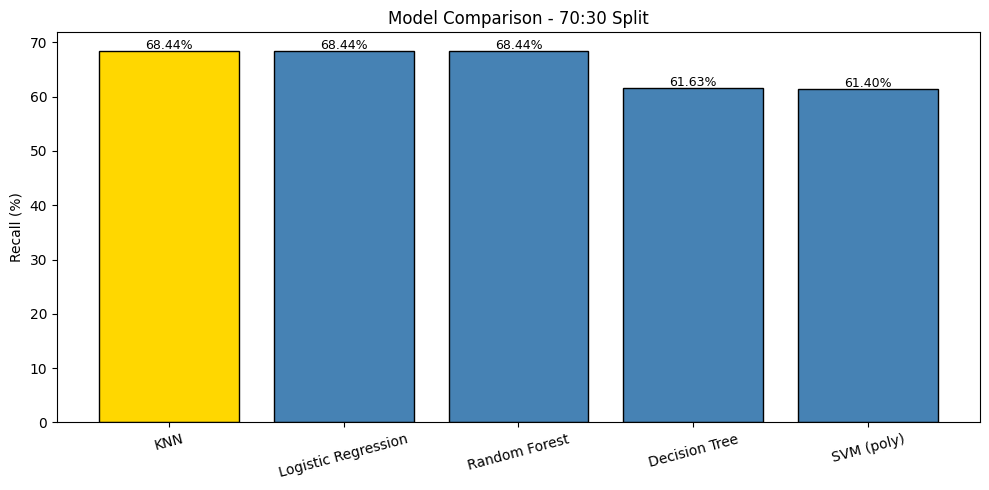


Best Model: KNN with 68.44% recall


In [24]:
# Bar chart
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(comparison_df))]
plt.bar(comparison_df['Model'], comparison_df['recall (%)'], color=colors, edgecolor='black')
for i, v in enumerate(comparison_df['recall (%)']):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontsize=9)
plt.ylabel('Recall (%)')
plt.title('Model Comparison - 70:30 Split')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
print(f'\nBest Model: {best_model_name} with {comparison_df.iloc[0]["recall (%)"]:.2f}% recall')

In [28]:
#saving fiimport pickle

with open('heart_model.pkl', 'wb') as f:
    pickle.dump(rf, f)                
    pickle.dump(scaler, f)            
    pickle.dump(selected_features, f) 

print("Model, Scaler, and Features saved successfully to heart_model.pkl!")

Files saved successfully!
